<font size="5" color="red"><b>ch3. 분류분석</b></font>
# 1절. 분류분석 개요
## 1-1 분류분석이란? 
- 타겟변수가 categorical인 분석
    * ex. 고객등급예측, 휴먼고객예측, 상품구매예측, 보험사기자예측
    * 수업ex. mnist 숫자데이터분류 예측, iris분류예측, 와인등급예측, 질병예측
- sklearning 패키지 : 머신러닝 모형, 예제데이터셋, 전처리 등의 기능 제공

## 1-2 샘플용 데이터 셋 접근
### load 계열(패키지 내에 데이터 있음)
    - load_iris(), load_boston(), load_diabetes()...
### fetch 계열(패키지 내에 데이터가 없고, 인터넷 연결시 다운)
    - fetch_openml(), fetch_rov1(로이터뉴스 말뭉치)
### make 계열(가상의 데이터 생성)
    - make_classification() : 분류분석용 데이터 생성
    - make_regression() : 회귀분석용 데이터 생성
    - make_blobs() : 군집분석용 데이터 생성(타겟변수 x)

In [3]:
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt
# mnist load
(X_train, y_train), (X_test, y_test) = mnist.load_data()
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((60000, 28, 28), (60000,), (10000, 28, 28), (10000,))

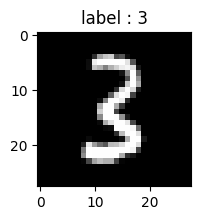

In [4]:
# 첫번째 이미지 출력
plt.figure(figsize=(2,2))
plt.imshow(X_train[50000], cmap='gray')
plt.title("label : {}".format(y_train[50000]))
plt.show()

In [8]:
# fetch 계열(패키지 내에 데이터가 없고, 인터넷 연결시 다운)
from sklearn.datasets import fetch_openml
# mnist fetch : mnist, iris, boston, fashon-mnist ....
mnist = fetch_openml(name="mnist_784", version=1, as_frame=False, parser="auto")
X, y = mnist.data, mnist.target.astype('int')
X.shape, y.shape

((70000, 784), (70000,))

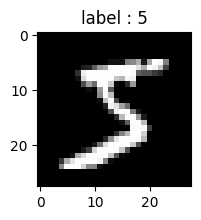

In [9]:
X = X.reshape(-1, 28,28)
# 첫번째 이미지 출력
plt.figure(figsize=(2,2))
plt.imshow(X[0], cmap='gray')
plt.title('label : {}'.format(y[0]))
plt.show()

# 2절. 분류분석의 종류
- predict()
## 2-1 확률적 모형
    - 주어진 데이터에 각 클래스가 정답일 확률을 계산하는 모형
    - predict_proba() : 각 분류 클래스별 확률을 알려줌(일부의 판별함수 모형에 있긴 함)
    - predict_log_proba() : 확률의 로그값을 알려줌

## 2-2 판별함수 모형
    - 주어진 데이터를 클래스에 따라 어떤 영역으로 나눠지는 경계면을 찾는 함수

In [2]:
import io
from sklearn.tree import export_graphviz
# conda install graphviz
import pydot # pip install pydot
from IPython.core.display import Image

In [3]:
def draw_decision_tree(model, feature_names):
 dot_buf = io.StringIO()
 export_graphviz(model, out_file=dot_buf, feature_names=feature_names)
 graph = pydot.graph_from_dot_data(dot_buf.getvalue())[0]
 image = graph.create_png()
 return Image(image)